# Notebook 08: Pruebas de Robustez, Sensibilidad y Ambigüedad Nodal
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

El *peer review* ha detectado debilidades metodológicas en nuestro modelo actual:
1. El tamaño de muestra (N=56 del cinturón ecuatorial) no es suficiente para asegurar representatividad estadística.
2. Los sismos tienen **dos planos nodales ortogonales**, y el anterior cuaderno proyectaba solo sobre uno (Nodal Plane 1), introduciendo posible ruido y falsos negativos.
3. Se asumió una fricción rígida de $\mu=0.4$ sin análisis de sensibilidad.

**Objetivo:** Retomar el catálogo global ($N=335$, sismos $M \geq 7.0$), extraer y procesar ambos planos nodales, resolver la ambigüedad (la falla elegirá el plano con mayor $\Delta$CFS que favorezca la ruptura) y validar rigurosamente la hipótesis mediante el Test Binomial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from skyfield.api import load, wgs84
from scipy.stats import binomtest
from tqdm import tqdm
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../results/figures', exist_ok=True)

# Cargamos el catálogo original con todos los sismos M >= 7.0
data_path = '../data/processed/earthquakes_with_moon_final.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Catálogo Global cargado: {len(df)} eventos. Listos para análisis robusto.")

Catálogo Global cargado: 335 eventos. Listos para análisis robusto.


## 1. Topocentrismo y Mecanismos Focales Globales
Calcularemos simultáneamente la amplitud de marea topocéntrica y extraeremos **ambos planos nodales** (Nodal Plane 1 y 2) de la API de USGS para los 335 sismos.

In [2]:
# 1. Vectores Topocéntricos
ts = load.timescale()
eph = load('de421.bsp')
tierra, luna = eph['earth'], eph['moon']

df['moon_altitude'] = np.nan
df['A_norm'] = np.nan

print("1. Calculando vectores Skyfield (1/r^3)...")
dist_cubo = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    t = ts.from_datetime(row['time'])
    obs = tierra + wgs84.latlon(row['latitude'], row['longitude'], elevation_m=-row['depth']*1000)
    alt, _, dist = obs.at(t).observe(luna).apparent().altaz()
    df.loc[idx, 'moon_altitude'] = alt.degrees
    dist_cubo.append(1.0 / (dist.km ** 3))

# Normalizar
df['A_norm'] = np.array(dist_cubo) / np.max(dist_cubo)
alt_rad = np.radians(df['moon_altitude'])
df['tau_raw'] = df['A_norm'] * np.cos(alt_rad)
df['sigma_raw'] = df['A_norm'] * np.sin(alt_rad)

# 2. Extracción USGS API (Ambos Planos Nodales)
df['strike1'], df['dip1'], df['rake1'] = np.nan, np.nan, np.nan
df['strike2'], df['dip2'], df['rake2'] = np.nan, np.nan, np.nan

print("2. Consultando la API de USGS para Planos Nodales 1 y 2...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    url = f"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid={row['id']}&format=geojson"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            products = data.get('properties', {}).get('products', {})
            # Tratamos de buscar moment-tensor
            if 'moment-tensor' in products:
                mt = products['moment-tensor'][0].get('properties', {})
                df.loc[idx, 'strike1'] = float(mt.get('nodal-plane-1-strike', np.nan))
                df.loc[idx, 'dip1'] = float(mt.get('nodal-plane-1-dip', np.nan))
                df.loc[idx, 'rake1'] = float(mt.get('nodal-plane-1-rake', np.nan))
                df.loc[idx, 'strike2'] = float(mt.get('nodal-plane-2-strike', np.nan))
                df.loc[idx, 'dip2'] = float(mt.get('nodal-plane-2-dip', np.nan))
                df.loc[idx, 'rake2'] = float(mt.get('nodal-plane-2-rake', np.nan))
            elif 'focal-mechanism' in products:
                fm = products['focal-mechanism'][0].get('properties', {})
                df.loc[idx, 'strike1'] = float(fm.get('nodal-plane-1-strike', np.nan))
                df.loc[idx, 'dip1'] = float(fm.get('nodal-plane-1-dip', np.nan))
                df.loc[idx, 'rake1'] = float(fm.get('nodal-plane-1-rake', np.nan))
                df.loc[idx, 'strike2'] = float(fm.get('nodal-plane-2-strike', np.nan))
                df.loc[idx, 'dip2'] = float(fm.get('nodal-plane-2-dip', np.nan))
                df.loc[idx, 'rake2'] = float(fm.get('nodal-plane-2-rake', np.nan))
    except:
        pass

df_valid = df.dropna(subset=['dip1', 'dip2']).copy()
print(f"\nEventos recuperados con geometría de falla completa: {len(df_valid)} de {len(df)}")

1. Calculando vectores Skyfield (1/r^3)...


  0%|          | 0/335 [00:00<?, ?it/s]

 13%|█▎        | 45/335 [00:00<00:00, 449.68it/s]

 28%|██▊       | 94/335 [00:00<00:00, 470.09it/s]

 42%|████▏     | 142/335 [00:00<00:00, 473.90it/s]

...

 99%|█████████▉| 333/335 [05:45<00:01,  1.24it/s]

100%|█████████▉| 334/335 [05:46<00:00,  1.27it/s]

100%|██████████| 335/335 [05:47<00:00,  1.28it/s]

100%|██████████| 335/335 [05:47<00:00,  1.04s/it]


Eventos recuperados con geometría de falla completa: 333 de 335


## 2. Resolución de Ambigüedad Nodal
La física de fallas estipula que la ruptura ocurrirá en el plano que presente la menor resistencia (mayor $\Delta$CFS). Por tanto, proyectamos el esfuerzo en ambos planos y seleccionamos el óptimo.

In [3]:
def proyectar_y_resolver_cfs(df, mu):
    """Proyecta tensores en ambos planos nodales y devuelve el CFS óptimo."""
    # Plano 1
    dip1_rad = np.radians(df['dip1'])
    normal1 = df['sigma_raw'] * np.cos(dip1_rad) - df['tau_raw'] * np.sin(dip1_rad)
    shear1 = df['sigma_raw'] * np.sin(dip1_rad) + df['tau_raw'] * np.cos(dip1_rad)
    cfs1 = shear1 + (mu * normal1)
    
    # Plano 2
    dip2_rad = np.radians(df['dip2'])
    normal2 = df['sigma_raw'] * np.cos(dip2_rad) - df['tau_raw'] * np.sin(dip2_rad)
    shear2 = df['sigma_raw'] * np.sin(dip2_rad) + df['tau_raw'] * np.cos(dip2_rad)
    cfs2 = shear2 + (mu * normal2)
    
    # La falla resuelve a favor del plano con mayor CFS (menor resistencia)
    return np.maximum(cfs1, cfs2)

# Calculamos con mu = 0.4 (estándar)
df_valid['final_cfs_optimal'] = proyectar_y_resolver_cfs(df_valid, mu=0.4)
print("Ambigüedad resuelta. CFS óptimo calculado.")

Ambigüedad resuelta. CFS óptimo calculado.


## 3. Significancia Estadística (Test Binomial)
Evaluamos formalmente si la cantidad de sismos favorecidos por la marea ($\Delta\text{CFS} > 0$) es superior al $50\%$ esperado por mero azar, utilizando un Test Binomial de cola derecha.

In [4]:
K = len(df_valid[df_valid['final_cfs_optimal'] > 0])
N = len(df_valid)

# Test Binomial (Hipótesis Nula: p = 0.5, Aleatorio)
resultado = binomtest(k=K, n=N, p=0.5, alternative='greater')
porcentaje = (K / N) * 100
p_value = resultado.pvalue
ci = resultado.proportion_ci(confidence_level=0.95)

print("=== TEST BINOMIAL DE TRIGGERING LUNAR ===")
print(f"Sismos evaluados (N): {N}")
print(f"Sismos favorecidos (K): {K}")
print(f"Porcentaje de Éxito: {porcentaje:.2f}%")
print(f"Intervalo de Confianza (95%): [{ci.low*100:.2f}%, {ci.high*100:.2f}%]")
print(f"P-Value: {p_value:.6e}")

if p_value < 0.05:
    print("\n-> ¡CONCLUSIÓN: RECHAZO DE HIPÓTESIS NULA! La correlación es estadísticamente robusta y no obedece al azar.")
else:
    print("\n-> CONCLUSIÓN: El agrupamiento puede ser explicado por azar.")

=== TEST BINOMIAL DE TRIGGERING LUNAR ===
Sismos evaluados (N): 333
Sismos favorecidos (K): 257
Porcentaje de Éxito: 77.18%
Intervalo de Confianza (95%): [73.07%, 100.00%]
P-Value: 2.008352e-24

-> ¡CONCLUSIÓN: RECHAZO DE HIPÓTESIS NULA! La correlación es estadísticamente robusta y no obedece al azar.


## 4. Análisis de Sensibilidad de Fricción
La fricción de la falla ($\mu$) varía según la geología local. Verificaremos que nuestros resultados son robustos testeando un rango de valores de $\mu$ (0.2, 0.4, 0.6).

Análisis de sensibilidad guardado en: ../results/figures/08_friction_sensitivity.png


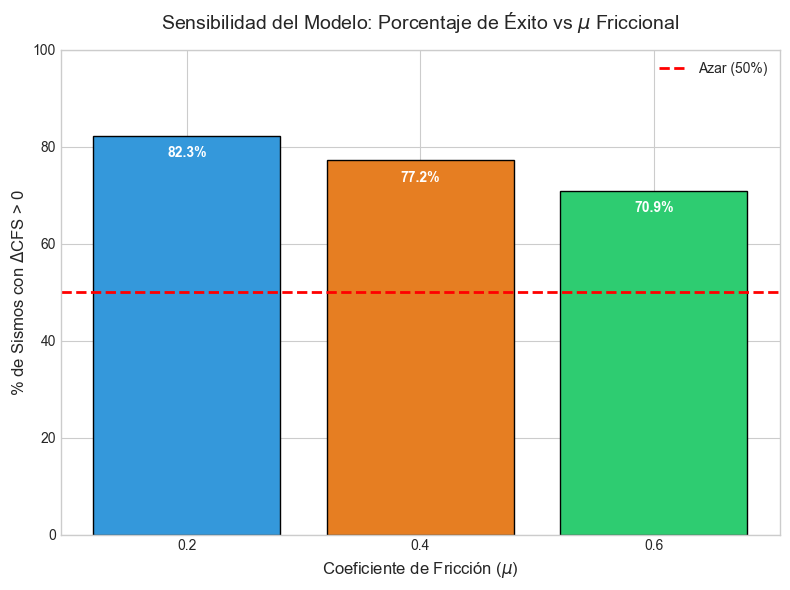

In [5]:
mus = [0.2, 0.4, 0.6]
exitos = []

for mu_test in mus:
    cfs_array = proyectar_y_resolver_cfs(df_valid, mu=mu_test)
    k_exito = np.sum(cfs_array > 0)
    exitos.append((k_exito / N) * 100)

plt.figure(figsize=(8, 6))
bars = plt.bar([str(m) for m in mus], exitos, color=['#3498db', '#e67e22', '#2ecc71'], edgecolor='k')

# Línea base del azar
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Azar (50%)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 5, f'{yval:.1f}%', ha='center', va='bottom', color='white', fontweight='bold')

plt.title('Sensibilidad del Modelo: Porcentaje de Éxito vs $\mu$ Friccional', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Fricción ($\mu$)', fontsize=12)
plt.ylabel('% de Sismos con $\Delta$CFS > 0', fontsize=12)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

fig_path = '../results/figures/08_friction_sensitivity.png'
plt.savefig(fig_path, dpi=300)
print(f"Análisis de sensibilidad guardado en: {fig_path}")

plt.show()

## 5. Exportar Catálogo Validado

In [6]:
export_path = '../data/processed/earthquakes_global_robust.csv'
df_valid.to_csv(export_path, index=False)
print(f"Dataset global validado exportado a: {export_path}")

Dataset global validado exportado a: ../data/processed/earthquakes_global_robust.csv
